In [1]:
import sys, os
# Erzwingt den Hauptpfad
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.db_connect import load_sql, get_engine

In [2]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import text

# Pfad-Setup: Damit Python den 'src'-Ordner findet
sys.path.append(os.path.abspath('..'))
from src.db_connect import get_engine

# Engine erstellen: Die Verbindung zur Datenbank aufbauen
engine = get_engine()

In [3]:
from sqlalchemy import text
import pandas as pd

# Abfrage aller SOFA-Subkategorien für deine Respiratory-Kohorte
query_all_subcategories = text("""
SELECT 
    c.hadm_id,
    c.gender,
    s.sofa_score AS gesamt_score,
    -- Hier sind alle 6 Subkategorien
    s.respiration AS lunge,
    s.coagulation AS blutgerinnung,
    s.liver AS leber,
    s.cardiovascular AS herz_kreislauf,
    s.cns AS nervensystem,
    s.renal AS niere
FROM cohort_respiratory c
LEFT JOIN sofa s ON c.hadm_id = s.hadm_id
ORDER BY s.sofa_score DESC
LIMIT 20;
""")

try:
    with engine.connect() as conn:
        df_sub = pd.read_sql(query_all_subcategories, conn)
    
    print("--- SOFA Detail-Check: Top 20 kränkste Patienten ---")
    # Formatiert die Ausgabe für bessere Lesbarkeit
    display(df_sub) 

except Exception as e:
    print(f"❌ Fehler bei der Abfrage: {e}")

--- SOFA Detail-Check: Top 20 kränkste Patienten ---


,hadm_id,gender,gesamt_score,lunge,blutgerinnung,leber,herz_kreislauf,nervensystem,niere
0,141633,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,119380,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,164142,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,152316,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,169754,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,101611,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,167988,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,186838,M,19.0,4.0,2.0,4.0,1.0,4.0,4.0
8,114904,M,19.0,4.0,4.0,2.0,1.0,4.0,4.0
9,117562,F,19.0,4.0,4.0,3.0,1.0,4.0,3.0


In [4]:
query_prone_bmi = text("""
WITH weight_data AS (
    -- Wir nehmen das erste gemessene Gewicht bei Aufnahme
    SELECT DISTINCT ON (hadm_id) hadm_id, valuenum as weight_kg
    FROM chartevents
    WHERE itemid IN (226512, 762) -- Metavision & CareVue Gewicht
    AND valuenum IS NOT NULL
    ORDER BY hadm_id, charttime ASC
),
prone_events AS (
    -- Erster Zeitpunkt der Bauchlage
    SELECT DISTINCT ON (hadm_id) hadm_id, charttime as first_prone_time
    FROM chartevents
    WHERE itemid = 224093 AND value = 'Prone'
    ORDER BY hadm_id, charttime ASC
)
SELECT 
    c.hadm_id,
    c.gender,
    c.age,
    w.weight_kg,
    s.sofa_score,
    s.respiration as sofa_resp,
    CASE WHEN p.first_prone_time IS NOT NULL THEN 1 ELSE 0 END as was_proned,
    EXTRACT(EPOCH FROM (p.first_prone_time - c.admittime))/3600 AS hours_to_prone
FROM cohort_respiratory c
LEFT JOIN weight_data w ON c.hadm_id = w.hadm_id
LEFT JOIN prone_events p ON c.hadm_id = p.hadm_id
LEFT JOIN sofa s ON c.hadm_id = s.hadm_id;
""")

with engine.connect() as conn:
    df_prone_study = pd.read_sql(query_prone_bmi, conn)

# Kleiner Check der ersten Zeilen
print(df_prone_study.head())

   hadm_id gender   age  weight_kg  sofa_score  sofa_resp  was_proned  \
0   189514      M  54.1        NaN         4.0        3.0           0   
1   152416      M  30.7       95.5         2.0        0.0           0   
2   199133      F  78.9       54.0         6.0        2.0           0   
3   129142      M  37.1      131.8         7.0        4.0           0   
4   112840      F  45.1      120.0        12.0        4.0           0   

   hours_to_prone  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  


In [5]:
query_prone_check = text("""
WITH weight_data AS (
    -- Erstes Gewicht bei Aufnahme
    SELECT DISTINCT ON (hadm_id) hadm_id, valuenum as weight_kg
    FROM chartevents
    WHERE itemid IN (226512, 762, 763, 224639) 
    AND valuenum IS NOT NULL
    ORDER BY hadm_id, charttime ASC
),
prone_events AS (
    -- Alle Patienten, die jemals auf dem Bauch lagen (Item 224093)
    SELECT DISTINCT hadm_id
    FROM chartevents
    WHERE itemid = 224093 AND value = 'Prone'
)
SELECT 
    c.hadm_id,
    c.gender,
    s.sofa_score,
    s.respiration as sofa_lunge,
    w.weight_kg,
    CASE WHEN p.hadm_id IS NOT NULL THEN 1 ELSE 0 END as wurde_gelagert
FROM cohort_respiratory c
LEFT JOIN sofa s ON c.hadm_id = s.hadm_id
LEFT JOIN weight_data w ON c.hadm_id = w.hadm_id
LEFT JOIN prone_events p ON c.hadm_id = p.hadm_id
WHERE s.sofa_score IS NOT NULL;
""")

with engine.connect() as conn:
    df_prone = pd.read_sql(query_prone_check, conn)

# Zeige die ersten Zeilen zur Kontrolle
display(df_prone.head())

,hadm_id,gender,sofa_score,sofa_lunge,weight_kg,wurde_gelagert
0,189514,M,4,3,82.400002,0
1,152416,M,2,0,95.500000,0
2,199133,F,6,2,54.000000,0
3,129142,M,7,4,146.700000,0
4,112840,F,12,4,120.000000,0


Prozentualer Anteil der Bauchlage nach Lungen-Schweregrad:
sofa_lunge
0    5.840939
1    0.000000
2    1.320132
3    1.355014
4    2.894648
Name: wurde_gelagert, dtype: float64


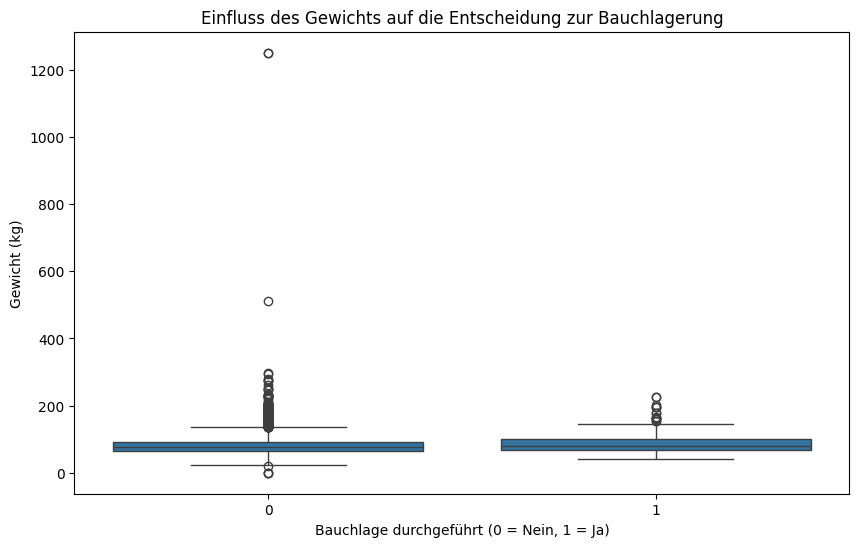

In [6]:
# Gruppierung nach Lungen-Score
prone_stats = df_prone.groupby('sofa_lunge')['wurde_gelagert'].mean() * 100

print("Prozentualer Anteil der Bauchlage nach Lungen-Schweregrad:")
print(prone_stats)

# Visualisierung der Gewichts-Barriere
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='wurde_gelagert', y='weight_kg', data=df_prone.dropna(subset=['weight_kg']))
plt.title('Einfluss des Gewichts auf die Entscheidung zur Bauchlagerung')
plt.xlabel('Bauchlage durchgeführt (0 = Nein, 1 = Ja)')
plt.ylabel('Gewicht (kg)')
plt.show()

In [7]:
# Bereinigung: Wir filtern unrealistische Gewichte (z.B. > 300kg) und NaN
df_clean = df_prone[(df_prone['weight_kg'] > 30) & (df_prone['weight_kg'] < 300)].dropna(subset=['weight_kg'])

# Vergleich der Statistiken
stats_weight = df_clean.groupby('wurde_gelagert')['weight_kg'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])

print("--- Gewichts-Statistiken nach Bauchlagerung ---")
print(stats_weight)

--- Gewichts-Statistiken nach Bauchlagerung ---
                count       mean        std  median   min    max
wurde_gelagert                                                  
0                8006  81.408701  26.031266    77.0  30.1  296.8
1                 334  86.978443  29.910905    80.0  40.0  225.0


In [8]:
# Filter für schwere Lungenfälle
heavy_lung_failure = df_prone[df_prone['sofa_lunge'] >= 3]

prone_rate_heavy = heavy_lung_failure.groupby('gender')['wurde_gelagert'].mean() * 100

print("\n--- Bauchlage-Rate bei schwerem Lungenversagen (SOFA Lunge 3-4) ---")
print(prone_rate_heavy)


--- Bauchlage-Rate bei schwerem Lungenversagen (SOFA Lunge 3-4) ---
gender
F    1.546906
M    3.069996
Name: wurde_gelagert, dtype: float64


In [9]:
# Wir gruppieren nach dem Lungen-Score UND dem Geschlecht
detail_stats = df_prone.groupby(['sofa_lunge', 'gender'])['wurde_gelagert'].agg(['count', 'sum', 'mean'])

# Umrechnung in Prozent für die bessere Lesbarkeit
detail_stats['quote_prozent'] = detail_stats['mean'] * 100

# Umbenennen der Spalten für die Präsentation
detail_stats.columns = ['Anzahl Patienten', 'Anzahl Gelagert', 'Anteil (0-1)', 'Quote in %']

print("--- Analyse nach Lungen-Schweregrad (SOFA) und Geschlecht ---")
display(detail_stats)

--- Analyse nach Lungen-Schweregrad (SOFA) und Geschlecht ---


Anzahl Patienten  Anzahl Gelagert  Anteil (0-1)  Quote in %
sofa_lunge gender                                                             
0          F                   1761               88      0.049972    4.997161
           M                   2074              136      0.065574    6.557377
1          F                     10                0      0.000000    0.000000
           M                      9                0      0.000000    0.000000
2          F                    146                1      0.006849    0.684932
           M                    157                3      0.019108    1.910828
3          F                    711                7      0.009845    0.984529
           M                    765               13      0.016993    1.699346
4          F                   1293               24      0.018561    1.856148
           M                   1678               62      0.036949    3.694875

In [10]:
# Wir erstellen Gewichtsklassen für eine bessere Übersicht
def weight_category(w):
    if w < 70: return '<70 kg'
    if w < 90: return '70-90 kg'
    if w < 110: return '90-110 kg'
    return '>110 kg'

# Daten bereinigen und Kategorien anwenden
df_analysis = df_prone.dropna(subset=['weight_kg', 'sofa_lunge']).copy()
df_analysis['weight_class'] = df_analysis['weight_kg'].apply(weight_category)

# Pivot-Tabelle erstellen: Durchschnittliche Rate der Bauchlagerung
heatmap_data = df_analysis.pivot_table(
    index='weight_class', 
    columns='sofa_lunge', 
    values='wurde_gelagert', 
    aggfunc='mean'
) * 100 # In Prozent umrechnen

# Sortierung der Index-Reihenfolge erzwingen
heatmap_data = heatmap_data.reindex(['<70 kg', '70-90 kg', '90-110 kg', '>110 kg'])

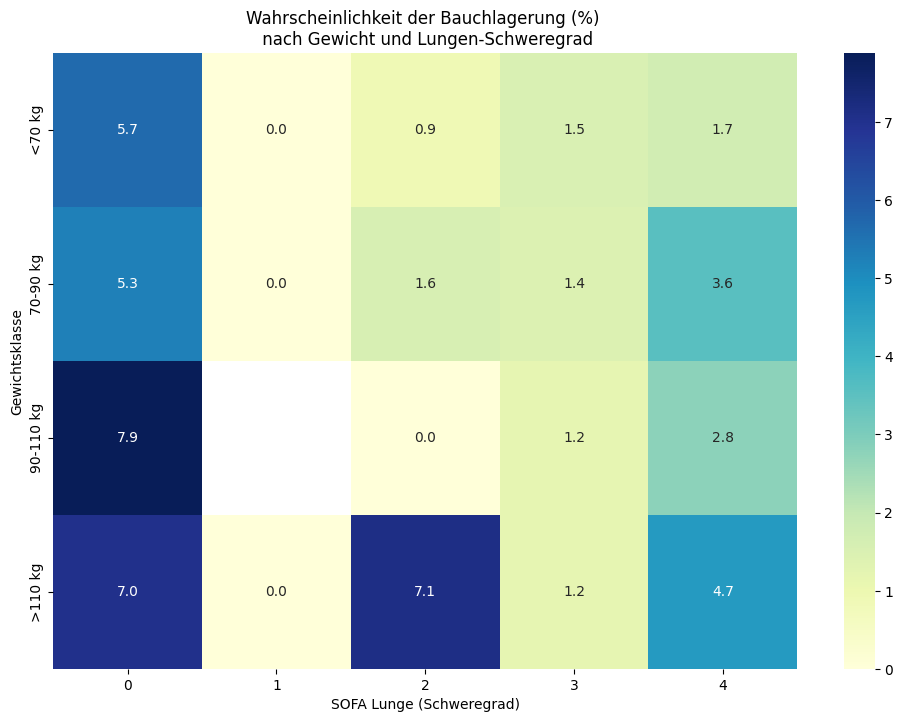

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Wahrscheinlichkeit der Bauchlagerung (%) \n nach Gewicht und Lungen-Schweregrad')
plt.xlabel('SOFA Lunge (Schweregrad, first 24h)')
plt.ylabel('Gewichtsklasse')
plt.show()

In [12]:
# Wir filtern nur die Schwerstkranken (SOFA Lunge 3-4), um einen fairen Vergleich zu haben
heavy_cases = df_prone[df_prone['sofa_lunge'] >= 3].copy()

# Wir brauchen die Sterbedaten aus der admissions Tabelle
query_mortality = text("""
SELECT hadm_id, hospital_expire_flag 
FROM admissions
""")

with engine.connect() as conn:
    df_mort = pd.read_sql(query_mortality, conn)

# Zusammenführen
df_effect = heavy_cases.merge(df_mort, on='hadm_id', how='left')

# Analyse: Sterberate Gelagert vs. Nicht Gelagert
mortality_analysis = df_effect.groupby('wurde_gelagert')['hospital_expire_flag'].mean() * 100

print("--- Sterberate bei schwerem Lungenversagen (SOFA 3-4) ---")
print(f"Nicht gelagert: {mortality_analysis[0]:.2f}%")
print(f"Gelagert:       {mortality_analysis[1]:.2f}%")

--- Sterberate bei schwerem Lungenversagen (SOFA 3-4) ---
Nicht gelagert: 31.28%
Gelagert:       19.81%


In [13]:
# Gewichtsklassen-Funktion (wie zuvor)
def weight_category(w):
    if w < 70: return '<70 kg'
    if w < 90: return '70-90 kg'
    if w < 110: return '90-110 kg'
    return '>110 kg'

# Admissions laden für Mortalität
query_mort = text("SELECT hadm_id, hospital_expire_flag FROM admissions")
with engine.connect() as conn:
    df_mort = pd.read_sql(query_mort, conn)

# Merge mit dem Haupt-Datensatz
df_full = df_prone.merge(df_mort, on='hadm_id', how='left')
df_full['weight_class'] = df_full['weight_kg'].apply(weight_category)

In [14]:
# Gruppierung nach Gewichtsklasse und Lagerung
mort_weight = df_full.groupby(['weight_class', 'wurde_gelagert'])['hospital_expire_flag'].mean() * 100
mort_weight = mort_weight.unstack().reindex(['<70 kg', '70-90 kg', '90-110 kg', '>110 kg'])
mort_weight.columns = ['Sterberate Nein (%)', 'Sterberate Ja (%)']

print("--- Mortalität nach Gewichtsklasse und Lagerung ---")
display(mort_weight)

--- Mortalität nach Gewichtsklasse und Lagerung ---


,Sterberate Nein (%),Sterberate Ja (%)
weight_class,,
<70 kg,34.824281,30.303030
70-90 kg,32.067511,21.929825
90-110 kg,27.960757,26.760563
>110 kg,24.619289,20.000000


In [15]:
# Gruppierung nach SOFA Lunge und Lagerung
mort_sofa = df_full.groupby(['sofa_lunge', 'wurde_gelagert'])['hospital_expire_flag'].mean() * 100
mort_sofa = mort_sofa.unstack()
mort_sofa.columns = ['Sterberate Nein (%)', 'Sterberate Ja (%)']

print("\n--- Mortalität nach SOFA Lunge und Lagerung ---")
display(mort_sofa)


--- Mortalität nach SOFA Lunge und Lagerung ---


,Sterberate Nein (%),Sterberate Ja (%)
sofa_lunge,,
0,31.847134,27.232143
1,10.526316,NaN
2,24.414716,50.000000
3,22.939560,10.000000
4,35.493934,22.093023


In [16]:
# Wir erstellen die große Pivot-Tabelle
# Index: SOFA Lunge und Gewichtsklasse
# Spalten: wurde_gelagert (0 oder 1)
# Werte: Durchschnitt der Sterberate (hospital_expire_flag)

summary_table = df_full.pivot_table(
    index=['sofa_lunge', 'weight_class'], 
    columns='wurde_gelagert', 
    values='hospital_expire_flag',
    aggfunc=['mean', 'count'] # Wir nehmen den Mittelwert (Rate) und die Anzahl (n)
)

# Verschönerung der Tabelle
# Wir multiplizieren die Mittelwerte mit 100 für Prozentangaben
summary_table['mean'] = summary_table['mean'] * 100

# Umbenennen für bessere Lesbarkeit
summary_table.columns = [
    'Sterberate % (Nein)', 'Sterberate % (Ja)', 
    'Anzahl n (Nein)', 'Anzahl n (Ja)'
]

# Sortierung der Gewichtsklassen innerhalb der Scores erzwingen
weight_order = ['<70 kg', '70-90 kg', '90-110 kg', '>110 kg']
summary_table = summary_table.reindex(weight_order, level='weight_class')

print("--- DIE GROSSE ANALYSE-TABELLE: MORTALITÄT NACH SCORE, GEWICHT UND LAGERUNG ---")
display(summary_table.round(2)) # Auf 2 Nachkommastellen gerundet

--- DIE GROSSE ANALYSE-TABELLE: MORTALITÄT NACH SCORE, GEWICHT UND LAGERUNG ---


Sterberate % (Nein)  Sterberate % (Ja)  \
sofa_lunge weight_class                                           
0          <70 kg                      35.01              30.14   
           70-90 kg                    33.25              25.00   
           90-110 kg                   28.43              26.42   
           >110 kg                     25.63              26.67   
1          <70 kg                      25.00                NaN   
           70-90 kg                     0.00                NaN   
           >110 kg                      0.00                NaN   
2          <70 kg                      29.63             100.00   
           70-90 kg                    23.62               0.00   
           90-110 kg                   22.22                NaN   
           >110 kg                     10.71             100.00   
3          <70 kg                      23.45              12.50   
           70-90 kg                    26.09              14.29   
           90-110 kg                   20.72               0.00   
           >110 kg                     16.99               0.00   
4          <70 kg                      41.30              35.29   
           70-90 kg                    34.80              18.92   
           90-110 kg                   31.29              33.33   
           >110 kg                     28.46               5.88   

                         Anzahl n (Nein)  Anzahl n (Ja)  
sofa_lunge weight_class                                  
0          <70 kg                 1214.0           73.0  
           70-90 kg               1224.0           68.0  
           90-110 kg               619.0           53.0  
           >110 kg                 554.0           30.0  
1          <70 kg                    8.0            NaN  
           70-90 kg                  7.0            NaN  
           >110 kg                   4.0            NaN  
2          <70 kg                  108.0            1.0  
           70-90 kg                127.0            2.0  
           90-110 kg                36.0            NaN  
           >110 kg                  28.0            1.0  
3          <70 kg                  516.0            8.0  
           70-90 kg                483.0            7.0  
           90-110 kg               251.0            3.0  
           >110 kg                 206.0            2.0  
4          <70 kg                  971.0           17.0  
           70-90 kg               1003.0           37.0  
           90-110 kg               521.0           15.0  
           >110 kg                 390.0           17.0

In [17]:
from scipy.stats import chi2_contingency

# Wir nehmen nur die Patienten mit schwerem Lungenversagen (SOFA 3-4)
df_sig = df_full[df_full['sofa_lunge'] >= 3].dropna(subset=['hospital_expire_flag', 'wurde_gelagert'])

# Erstellen einer Kreuztabelle (Contingency Table)
contingency_table = pd.crosstab(df_sig['wurde_gelagert'], df_sig['hospital_expire_flag'])

# Test durchführen
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Quadrat-Test Ergebnis:")
print(f"P-Wert: {p_value:.10f}") # Zeigt 10 Nachkommastellen

if p_value < 0.05:
    print("Ergebnis ist SIGNIFIKANT (p < 0.05)")
else:
    print("Ergebnis ist NICHT signifikant")

Chi-Quadrat-Test Ergebnis:
P-Wert: 0.0156642384
Ergebnis ist SIGNIFIKANT (p < 0.05)


In [18]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

# 1. Wir bereiten die Grunddaten vor (Zählen von Verstorbenen/Überlebenden)
# Wir brauchen die absoluten Zahlen für den Test
df_counts = df_full.groupby(['sofa_lunge', 'weight_class', 'wurde_gelagert', 'hospital_expire_flag']).size().unstack(fill_value=0)
# Falls Spalten fehlen (z.B. nur Überlebende), sicherstellen dass 0.0 und 1.0 da sind
for col in [0.0, 1.0]:
    if col not in df_counts.columns: df_counts[col] = 0

# 2. Funktion für den Chi-Quadrat Test pro Zeile
def get_p_value(row_index, df_source):
    try:
        # Extrahiere die 2x2 Matrix für diese Subgruppe
        # Matrix: [[Überlebt_Nein, Verstorben_Nein], [Überlebt_Ja, Verstorben_Ja]]
        nein_vals = df_source.loc[(row_index[0], row_index[1], 0)].values
        ja_vals = df_source.loc[(row_index[0], row_index[1], 1)].values
        
        obs = np.array([nein_vals, ja_vals])
        
        # Test nur durchführen, wenn in beiden Gruppen Patienten sind
        if obs.sum(axis=1).all():
            _, p, _, _ = chi2_contingency(obs)
            return p
        return np.nan
    except:
        return np.nan

# 3. Erstelle die finale Tabelle
summary_final = summary_table.copy()
summary_final['p-Wert'] = [get_p_value(idx, df_counts) for idx in summary_final.index]

# Markierung für Signifikanz hinzufügen
summary_final['Signifikant?'] = summary_final['p-Wert'].apply(lambda x: 'Ja' if x < 0.05 else 'Nein')

print("--- DETAILLIERTE ANALYSE MIT SIGNIFIKANZ-TEST PRO SUBGRUPPE ---")
display(summary_final.round(4))

--- DETAILLIERTE ANALYSE MIT SIGNIFIKANZ-TEST PRO SUBGRUPPE ---


Sterberate % (Nein)  Sterberate % (Ja)  \
sofa_lunge weight_class                                           
0          <70 kg                    35.0082            30.1370   
           70-90 kg                  33.2516            25.0000   
           90-110 kg                 28.4330            26.4151   
           >110 kg                   25.6318            26.6667   
1          <70 kg                    25.0000                NaN   
           70-90 kg                   0.0000                NaN   
           >110 kg                    0.0000                NaN   
2          <70 kg                    29.6296           100.0000   
           70-90 kg                  23.6220             0.0000   
           90-110 kg                 22.2222                NaN   
           >110 kg                   10.7143           100.0000   
3          <70 kg                    23.4496            12.5000   
           70-90 kg                  26.0870            14.2857   
           90-110 kg                 20.7171             0.0000   
           >110 kg                   16.9903             0.0000   
4          <70 kg                    41.2976            35.2941   
           70-90 kg                  34.7956            18.9189   
           90-110 kg                 31.2860            33.3333   
           >110 kg                   28.4615             5.8824   

                         Anzahl n (Nein)  Anzahl n (Ja)  p-Wert Signifikant?  
sofa_lunge weight_class                                                       
0          <70 kg                 1214.0           73.0  0.4700         Nein  
           70-90 kg               1224.0           68.0  0.2013         Nein  
           90-110 kg               619.0           53.0  0.8775         Nein  
           >110 kg                 554.0           30.0  1.0000         Nein  
1          <70 kg                    8.0            NaN     NaN         Nein  
           70-90 kg                  7.0            NaN     NaN         Nein  
           >110 kg                   4.0            NaN     NaN         Nein  
2          <70 kg                  108.0            1.0  0.6663         Nein  
           70-90 kg                127.0            2.0  1.0000         Nein  
           90-110 kg                36.0            NaN     NaN         Nein  
           >110 kg                  28.0            1.0  0.2853         Nein  
3          <70 kg                  516.0            8.0  0.7599         Nein  
           70-90 kg                483.0            7.0  0.7848         Nein  
           90-110 kg               251.0            3.0  0.8695         Nein  
           >110 kg                 206.0            2.0  1.0000         Nein  
4          <70 kg                  971.0           17.0  0.8026         Nein  
           70-90 kg               1003.0           37.0  0.0684         Nein  
           90-110 kg               521.0           15.0  1.0000         Nein  
           >110 kg                 390.0           17.0  0.0779         Nein

In [19]:
# 1. Daten nach Gewichtsklassen und Lagerung gruppieren (Zahlen für Verstorben/Überlebt)
df_weight_only = df_full.groupby(['weight_class', 'wurde_gelagert', 'hospital_expire_flag']).size().unstack(fill_value=0)

# 2. Funktion für den Chi-Quadrat Test (nur für Gewichtsklassen)
def get_p_weight(weight_cat, df_source):
    try:
        # Matrix: [[Überlebt_Nein, Verstorben_Nein], [Überlebt_Ja, Verstorben_Ja]]
        nein_vals = df_source.loc[(weight_cat, 0)].values
        ja_vals = df_source.loc[(weight_cat, 1)].values
        obs = np.array([nein_vals, ja_vals])
        if obs.sum(axis=1).all():
            _, p, _, _ = chi2_contingency(obs)
            return p
        return np.nan
    except: return np.nan

# 3. Übersichtstabelle erstellen
weight_summary = df_full.pivot_table(
    index='weight_class', 
    columns='wurde_gelagert', 
    values='hospital_expire_flag',
    aggfunc=['mean', 'count']
)

# Verschönern
weight_summary.columns = ['Mortalität % (Nein)', 'Mortalität % (Ja)', 'n (Nein)', 'n (Ja)']
weight_summary.iloc[:, 0:2] *= 100
weight_summary = weight_summary.reindex(['<70 kg', '70-90 kg', '90-110 kg', '>110 kg'])

# P-Werte hinzufügen
weight_summary['p-Wert'] = [get_p_weight(idx, df_weight_only) for idx in weight_summary.index]
weight_summary['Signifikant?'] = weight_summary['p-Wert'].apply(lambda x: 'Ja' if x < 0.05 else 'Nein')

print("--- ANALYSE DER EFFEKTIVITÄT NACH GEWICHTSKLASSEN (Über alle SOFA-Scores) ---")
display(weight_summary.round(4))

--- ANALYSE DER EFFEKTIVITÄT NACH GEWICHTSKLASSEN (Über alle SOFA-Scores) ---


,Mortalität % (Nein),Mortalität % (Ja),n (Nein),n (Ja),p-Wert,Signifikant?
weight_class,,,,,,
<70 kg,34.8243,30.3030,2817,99,0.4113,Nein
70-90 kg,32.0675,21.9298,2844,114,0.0294,Ja
90-110 kg,27.9608,26.7606,1427,71,0.9326,Nein
>110 kg,24.6193,20.0000,1182,50,0.5642,Nein


In [20]:
# Neue Kategorisierung definieren
def weight_category_compact(w):
    if w < 70: return '<70 kg'
    if w < 90: return '70-90 kg'
    return '>90 kg' # Zusammengefasst

df_full['weight_class_compact'] = df_full['weight_kg'].apply(weight_category_compact)

# Statistik berechnen
compact_summary = df_full.groupby(['weight_class_compact', 'wurde_gelagert'])['hospital_expire_flag'].agg(['mean', 'count'])
compact_summary['mean'] *= 100
compact_summary.columns = ['Mortalität %', 'Anzahl n']

print("--- KOMPAKTE ANALYSE (>90 kg zusammengefasst) ---")
display(compact_summary.unstack().round(2))

--- KOMPAKTE ANALYSE (>90 kg zusammengefasst) ---


Mortalität %        Anzahl n     
wurde_gelagert                  0      1        0    1
weight_class_compact                                  
70-90 kg                    32.07  21.93     2844  114
<70 kg                      34.82  30.30     2817   99
>90 kg                      26.45  23.97     2609  121

In [21]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Neue kompakte Kategorisierung anwenden
def weight_category_compact(w):
    if w < 70: return '1. <70 kg'
    if w < 90: return '2. 70-90 kg'
    return '3. >90 kg' # Zusammengefasste Gruppe

df_full['weight_class_compact'] = df_full['weight_kg'].apply(weight_category_compact)

# 2. Funktion für den Chi-Quadrat Test
def get_p_compact(cat, df):
    sub = df[df['weight_class_compact'] == cat]
    ct = pd.crosstab(sub['wurde_gelagert'], sub['hospital_expire_flag'])
    if ct.shape == (2, 2): # Sicherstellen, dass beide Gruppen vorhanden sind
        _, p, _, _ = chi2_contingency(ct)
        return p
    return np.nan

# 3. Ergebnistabelle bauen
results = []
for cat in sorted(df_full['weight_class_compact'].unique()):
    sub = df_full[df_full['weight_class_compact'] == cat]
    
    # Berechnungen pro Gruppe
    mort_nein = sub[sub['wurde_gelagert'] == 0]['hospital_expire_flag'].mean() * 100
    mort_ja = sub[sub['wurde_gelagert'] == 1]['hospital_expire_flag'].mean() * 100
    n_nein = len(sub[sub['wurde_gelagert'] == 0])
    n_ja = len(sub[sub['wurde_gelagert'] == 1])
    p_val = get_p_compact(cat, df_full)
    
    results.append({
        'Gewichtsklasse': cat,
        'Mortalität % (Nein)': mort_nein,
        'Mortalität % (Ja)': mort_ja,
        'n (Nein)': n_nein,
        'n (Ja)': n_ja,
        'p-Wert': p_val
    })

df_final_stat = pd.DataFrame(results).set_index('Gewichtsklasse')
df_final_stat['Signifikant?'] = df_final_stat['p-Wert'].apply(lambda x: 'JA' if x < 0.05 else 'Nein')

print("--- FINALE STATISTIK: KOMPAKTE GEWICHTSKLASSEN ---")
display(df_final_stat.round(4))

--- FINALE STATISTIK: KOMPAKTE GEWICHTSKLASSEN ---


,Mortalität % (Nein),Mortalität % (Ja),n (Nein),n (Ja),p-Wert,Signifikant?
Gewichtsklasse,,,,,,
1. <70 kg,34.8243,30.3030,2817,99,0.4113,Nein
2. 70-90 kg,32.0675,21.9298,2844,114,0.0294,JA
3. >90 kg,26.4469,23.9669,2609,121,0.6171,Nein


In [22]:
# Wir laden die Körpergröße dazu (oft in cm in MIMIC hinterlegt)
query_height = text("""
SELECT hadm_id, 
       valuenum as height_cm
FROM chartevents 
WHERE itemid IN (920, 226707) -- IDs für Körpergröße
AND valuenum IS NOT NULL
""")

with engine.connect() as conn:
    df_height = pd.read_sql(query_height, conn)
    # Wir nehmen den Durchschnittswert pro Aufenthalt, falls es mehrere gibt
    df_height = df_height.groupby('hadm_id')['height_cm'].mean().reset_index()

# Zusammenführen mit deinem bisherigen Datensatz (df_full)
df_bmi = df_full.merge(df_height, on='hadm_id', how='left')

# BMI berechnen: Gewicht (kg) / (Größe (m))^2
# Wir filtern unrealistische Werte (Ausreißer) direkt mit aus
df_bmi['bmi'] = df_bmi['weight_kg'] / ((df_bmi['height_cm'] / 100) ** 2)
df_bmi = df_bmi[(df_bmi['bmi'] > 10) & (df_bmi['bmi'] < 100)] # Plausibilitäts-Check

# BMI Kategorien definieren
def bmi_category(bmi):
    if bmi < 25: return '1. Normal/Untergewicht'
    if bmi < 30: return '2. Übergewicht (25-30)'
    return '3. Adipositas (>30)' # Zusammengefasst für Power

df_bmi['bmi_class'] = df_bmi['bmi'].apply(bmi_category)

In [23]:
results_bmi = []
for cat in sorted(df_bmi['bmi_class'].unique()):
    sub = df_bmi[df_bmi['bmi_class'] == cat]
    
    ct = pd.crosstab(sub['wurde_gelagert'], sub['hospital_expire_flag'])
    p_val = chi2_contingency(ct)[1] if ct.shape == (2, 2) else np.nan
    
    results_bmi.append({
        'BMI Klasse': cat,
        'Mortalität % (Nein)': sub[sub['wurde_gelagert'] == 0]['hospital_expire_flag'].mean() * 100,
        'Mortalität % (Ja)': sub[sub['wurde_gelagert'] == 1]['hospital_expire_flag'].mean() * 100,
        'n (Ja)': len(sub[sub['wurde_gelagert'] == 1]),
        'p-Wert': p_val
    })

df_final_bmi = pd.DataFrame(results_bmi).set_index('BMI Klasse')
df_final_bmi['Signifikant?'] = df_final_bmi['p-Wert'].apply(lambda x: 'JA' if x < 0.05 else 'Nein')

print("--- ANALYSE NACH BMI-KLASSEN ---")
display(df_final_bmi.round(4))

--- ANALYSE NACH BMI-KLASSEN ---


,Mortalität % (Nein),Mortalität % (Ja),n (Ja),p-Wert,Signifikant?
BMI Klasse,,,,,
1. Normal/Untergewicht,0.0000,NaN,0,NaN,Nein
3. Adipositas (>30),30.7692,NaN,0,NaN,Nein


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sqlalchemy import text

# 1. Körpergröße über hadm_id abrufen
query_bmi_v4 = text("""
SELECT hadm_id, AVG(valuenum) as height
FROM chartevents 
WHERE itemid IN (920, 1394, 226707) 
AND valuenum IS NOT NULL AND valuenum > 0
GROUP BY hadm_id
""")

with engine.connect() as conn:
    df_height_new = pd.read_sql(query_bmi_v4, conn)

# 2. Den richtigen Datensatz finden und mergen
# Wir nutzen die Tabelle, die du gerade aktiv hast (df_full oder df_prone)
target_df = df_full if 'df_full' in locals() else df_prone

# Sicherstellen, dass die Mortalität dabei ist
if 'hospital_expire_flag' not in target_df.columns:
    query_mort = text("SELECT hadm_id, hospital_expire_flag FROM admissions")
    with engine.connect() as conn:
        df_mort_back = pd.read_sql(query_mort, conn)
    target_df = target_df.merge(df_mort_back, on='hadm_id', how='left')

# Jetzt der Merge mit der Körpergröße
df_bmi_final = target_df.merge(df_height_new, on='hadm_id', how='left')

# 3. BMI berechnen (Plausibilitätscheck: Gewicht zwischen 30 und 300kg, Größe > 100cm)
df_bmi_final['bmi'] = df_bmi_final['weight_kg'] / ((df_bmi_final['height'] / 100) ** 2)

def bmi_cat(bmi):
    if pd.isna(bmi) or bmi < 12 or bmi > 70: return None
    if bmi < 25: return '1. Normal/Untergewicht (<25)'
    if bmi < 30: return '2. Übergewicht (25-30)'
    return '3. Adipositas (>30)'

df_bmi_final['bmi_class'] = df_bmi_final['bmi'].apply(bmi_cat)

# 4. Statistische Auswertung
bmi_results = []
for cat in ['1. Normal/Untergewicht (<25)', '2. Übergewicht (25-30)', '3. Adipositas (>30)']:
    sub = df_bmi_final[df_bmi_final['bmi_class'] == cat].dropna(subset=['hospital_expire_flag'])
    
    n_ja = len(sub[sub['wurde_gelagert'] == 1])
    if n_ja > 0:
        ct = pd.crosstab(sub['wurde_gelagert'], sub['hospital_expire_flag'])
        p = chi2_contingency(ct)[1] if ct.shape == (2, 2) else np.nan
        
        bmi_results.append({
            'BMI Klasse': cat,
            'Mortalität % (Nein)': sub[sub['wurde_gelagert'] == 0]['hospital_expire_flag'].mean() * 100,
            'Mortalität % (Ja)': sub[sub['wurde_gelagert'] == 1]['hospital_expire_flag'].mean() * 100,
            'n (Ja)': n_ja,
            'p-Wert': p
        })

df_bmi_stats = pd.DataFrame(bmi_results).set_index('BMI Klasse')
df_bmi_stats['Signifikant?'] = df_bmi_stats['p-Wert'].apply(lambda x: 'JA' if x < 0.05 else 'Nein')

print("--- FINALE BMI ANALYSE (Merge via hadm_id) ---")
display(df_bmi_stats.round(4))
print(f"\nPatienten mit berechenbarem BMI in der Kohorte: {df_bmi_final['bmi'].notna().sum()}")

KeyError: "None of ['BMI Klasse'] are in the columns"